<style>
h1 { font-size: 1.9em !important; font-weight: 700 !important; margin-top: 0.4em !important; }
h2 { font-size: 1.45em !important; font-weight: 700 !important; margin-top: 1.4em !important; padding-bottom: 0.25em !important; border-bottom: 1px solid #d0d7de !important; }
h3 { font-size: 1.18em !important; font-weight: 700 !important; margin-top: 1.1em !important; }
h4 { font-size: 1.05em !important; font-weight: 700 !important; }
p, li { font-size: 1em !important; line-height: 1.75 !important; }
table { font-size: 0.92em !important; }
blockquote { font-size: 0.95em !important; color: #57606a !important; }
</style>

#Portfolio Optimisation × Quantum Annealing

In this notebook, you learn the process of solving a portfolio optimisation problem using quantum annealing.

Portfolio optimization is an optimization problem that seeks to determine an investment allocation that ‘maximises returns (profits) whilst minimising risk’. In the paper we will be referring to, this problem is formulated as a QUBO (Quadratic Unconstrained Binary Optimisation) problem and applied to real-world financial data using quantum annealing.

Reference: [S.Wolfgang,et al. "A real-world test of portfolio optimization with quantum annealing.", 2025](https://link.springer.com/article/10.1007/s42484-025-00268-2)


In this hands-on session, we implement portfolio optimization following the steps below.

* Understand the basic concepts of portfolio optimisation
* Convert the optimisation problem into a QUBO
* Solve the QUBO using Simulated Annealing (SA) and quantum annealing
* Evaluate the resulting investment allocation through backtesting

We will explain technical terms as clearly as possible as we proceed. Let’s learn the entire process of optimisation using quantum annealing whilst running the code.

## Glossary

The basics of QUBO and SA/QA themselves are assumed to be prior knowledge and are not explained here. This section briefly collects the finance-related terms and notebook-specific vocabulary instead.

| Term | Meaning |
|---|---|
| Risk | The general possibility that things don't go as expected (covers both downside and upside) |
| Volatility | One concrete, numerical way of measuring risk (how much prices swing). This notebook treats "risk = volatility" (a common assumption in Markowitz-style optimization) |
| Target volatility | The upper bound on volatility — "risk must not go above this line" |
| Return | How much an investment grew (usually expressed as an annualized rate) |
| Iterative update | When a single pass can't give an exact answer: compute with a provisional value, use the result to update that value, recompute, and repeat, gradually improving precision |
| Slack variable | An auxiliary variable added to turn an inequality constraint ("at most" / "at least") into an equality by filling in the remaining slack |


## Background: What exactly is the problem?

### What is portfolio optimization?

Put simply, it is **the problem of determining how to allocate investments across different assets**.

For example, suppose you have 1 million yen and can invest it in three assets: Share A, Share B and Bond C.

- If you put it all into A, your investment might grow significantly if things go well, but you could suffer a huge loss if they don’t (high risk, high return)
- If you put it all into C, the increase will be small, but you are also less likely to suffer a major loss (low risk, low return)

What allocation should you use to maximise the expected return whilst keeping risk below a certain level?
Banks and asset management companies carry out these calculations on a daily basis.

In [1]:
# Colab / only needed once in a new environment
%pip install -q dwave-samplers dwave-system yfinance


In [2]:
# Imports, and display/plot settings used throughout the notebook
import datetime as dt
from pathlib import Path

import numpy as np
from dwave.samplers import SimulatedAnnealingSampler
import pandas as pd
import yfinance as yf

import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 110
np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.max_rows", 20)

## 1. Data: what are we investing in?

Here we use 10 "ETFs" (Exchange-Traded Funds) as the investable assets. An ETF is a financial product that bundles many stocks or bonds together and lets them be traded as a single item on an exchange. Instead of picking individual company stocks one by one, you can invest in a broad unit such as "the entire US stock market" or "the entire emerging-market stock market."

The paper uses private bank data, but from the filenames of the paper's figures we can infer that it used 10 assets, further broken down by region and type within three asset classes: "equities (EQ)," "fixed income (FI)," and "money market (MM)." So we substitute real, public ETFs for each of these (for example, "EQ_USA" is substituted with an ETF that invests in the entire US stock market).

A bit more detail on the asset classes:

| Class | Meaning | Characteristics |
|---|---|---|
| **EQ** (equities) | A security representing partial ownership of a company | More upside potential, but also more price swings |
| **FI** (fixed income) | A "loan" to a country or company | Pays a fixed interest rate; calmer price movement than equities |
| ├ investment grade | Loans to companies with high creditworthiness (low default risk) | Lower interest |
| └ high yield | Loans to companies with lower creditworthiness (higher default risk) | Higher interest (a.k.a. high-yield bonds) |
| **MM** (money market) | A collection of government securities with very short maturities (months to a few years) | Little sensitivity to rate changes; the calmest price movement of the three |

"Short-term" refers to the maturity of the securities the fund holds, not to us trading the ETF itself short-term (Section 5 does the opposite — a long-hold backtest).

How to read the table shown below:

| Column | Meaning |
|---|---|
| annual_return | How much, on average per year, this ETF's value tended to grow (based on historical data; the larger the positive number, the more it "tends to grow") |
| annual_volatility | How violently the price swings up and down (the larger the value, the "choppier" the price movement — i.e. the higher the risk) |

In general, assets with higher returns also tend to have higher volatility (risk) — how to balance that trade-off is the core of portfolio optimization.

**Data Acquisition**:
Instead of using proprietary banking data, historical price data for ten real-world ETFs are retrieved from Yahoo Finance. The annualized expected returns and the covariance matrix are then calculated from these historical prices for use in the portfolio optimization model.

Yahoo Finance data is intended for personal use only. [Yahoo API Terms of Use](https://legal.yahoo.com/us/en/yahoo/terms/product-atos/apiforydn/index.html?utm_sour)

In [3]:
# Set up the price-data cache dir, define the investment universe (10 ETFs across 3 classes), and the training/validation date ranges
CACHE_DIR = Path("cache")
CACHE_DIR.mkdir(exist_ok=True)

# Public, liquid ETFs chosen as substitutes for the paper's private assets (3 classes, 10 assets). Ticker -> (display name, asset class).
TICKERS: dict[str, tuple[str, str]] = {
    "VTI":  ("EQ_USA", "EQ"),
    "VGK":  ("EQ_EUROPE", "EQ"),
    "VWO":  ("EQ_EM", "EQ"),
    "IEF":  ("FI_USA", "FI"),
    "LQD":  ("FI_CREDIT_INVESTMENT_GRADE", "FI"),
    "HYG":  ("FI_CREDIT_HIGH_YIELD", "FI"),
    "IGOV": ("FI_EMU", "FI"),
    "BNDX": ("FI_EUROBONDS_HEDGED", "FI"),
    "BIL":  ("MM_MONEY_MARKET", "MM"),
    "SHY":  ("MM_SHORT_TERM_GOVERNMENT_BONDS", "MM"),
}
tickers = list(TICKERS.keys())

DEFAULT_START = "2013-06-04"  # earliest date for which price data is available for all 10 tickers
TRAIN_END = "2024-12-31"      # optimization uses only data up through this date (the training period)
TEST_START = "2025-01-01"     # data from here on is never used for optimization; held out for Section 5's validation
TRADING_DAYS_PER_YEAR = 252

In [4]:
# Fetch price data for the training period (read from cache if available)
cache_file = CACHE_DIR / f"prices_{DEFAULT_START}_{TRAIN_END}.csv"
if cache_file.exists():
    prices = pd.read_csv(cache_file, index_col=0, parse_dates=True)[tickers]
else:
    raw = yf.download(tickers, start=DEFAULT_START, end=TRAIN_END, progress=False, auto_adjust=True)["Close"]
    prices = raw[tickers].dropna()
    prices.to_csv(cache_file)

In [5]:
log_returns = np.log(prices[tickers] / prices[tickers].shift(1)).dropna()
# Annualized return
r = log_returns.mean().to_numpy() * TRADING_DAYS_PER_YEAR
# Annualized covariance matrix
sigma = log_returns.cov().to_numpy() * TRADING_DAYS_PER_YEAR
labels = [TICKERS[t][0] for t in TICKERS]
classes = [TICKERS[t][1] for t in TICKERS]
n = len(labels)

In [6]:
# Build and display a summary table of each asset's annualized return and volatility
asset_df = pd.DataFrame({
    "label": labels,
    "annual_return": r,
    "annual_volatility": np.sqrt(np.diag(sigma)),
})
print(f"Training period: {DEFAULT_START} to {TRAIN_END}  ({len(prices)} trading days)")
asset_df

Training period: 2013-06-04 to 2024-12-31  (2914 trading days)


,label,annual_return,annual_volatility
0,EQ_USA,0.124983,0.173025
1,EQ_EUROPE,0.052194,0.185214
2,EQ_EM,0.034978,0.197139
3,FI_USA,0.009173,0.065968
4,FI_CREDIT_INVESTMENT_GRADE,0.026429,0.082416
5,FI_CREDIT_HIGH_YIELD,0.039301,0.082430
6,FI_EMU,-0.016856,0.083980
7,FI_EUROBONDS_HEDGED,0.023212,0.039155
8,MM_MONEY_MARKET,0.013675,0.002659
9,MM_SHORT_TERM_GOVERNMENT_BONDS,0.011287,0.014372


## 2. Problem Definition: Summarising Assets, Constraints and Risk Limits

Here, we define the problem we are about to solve: which assets we can invest in, the constraints for each asset class (for example, ‘up to 60 per cent in equities’), and ‘how much risk we are willing to accept (target volatility)’.

‘Target volatility’ (the upper limit of acceptable risk) represents the line beyond which we must not take any further risk. In this instance, we will use a fixed value for this (by setting an acceptable risk limit, taking risk right up to the limit increases returns and generates profit, meaning we will actually end up taking risk close to that upper limit).

Furthermore, we will optimise using **data from 4 June 2013 to 31 December 2024 only**. Data from the period after that (from 1 January 2025 onwards) will not be used at all for optimisation; instead, it will be used in Section 5 to verify whether ‘the asset allocation actually generated a profit’.

Separating the data used for training from that used for validation is a common practice in machine learning and other fields, designed to verify whether the model ‘functions reasonably well even with data it has never seen before’, rather than simply ‘memorising past answers’.

**Problem Statement**: Define the constraints for each asset class and the upper limit on risk (target volatility) as constants.

In [7]:
# Define each asset's allocation bounds, the per-class constraints, and the risk cap (target volatility)
w_min = np.zeros(n)
w_max = np.full(n, 0.35)

class_constraints = [
    ("EQ", "<=", 0.60),
    ("FI", ">=", 0.25),
    ("MM", ">=", 0.05),
]

SIGMA_TARGET = 0.0771  # target volatility. A fixed value chosen in advance, outside this notebook, so that the risk cap is actually binding

In [8]:
# Display a summary table of the constraints defined above
spec_df = pd.DataFrame({
    "label": labels, "class": classes,
    "expected_return": r, "w_min": w_min, "w_max": w_max,
})
print(f"Number of assets: {n}")
print(f"target volatility (risk cap) = {SIGMA_TARGET:.4%}")
spec_df

Number of assets: 10
target volatility (risk cap) = 7.7100%


,label,class,expected_return,w_min,w_max
0,EQ_USA,EQ,0.124983,0.0,0.35
1,EQ_EUROPE,EQ,0.052194,0.0,0.35
2,EQ_EM,EQ,0.034978,0.0,0.35
3,FI_USA,FI,0.009173,0.0,0.35
4,FI_CREDIT_INVESTMENT_GRADE,FI,0.026429,0.0,0.35
5,FI_CREDIT_HIGH_YIELD,FI,0.039301,0.0,0.35
6,FI_EMU,FI,-0.016856,0.0,0.35
7,FI_EUROBONDS_HEDGED,FI,0.023212,0.0,0.35
8,MM_MONEY_MARKET,MM,0.013675,0.0,0.35
9,MM_SHORT_TERM_GOVERNMENT_BONDS,MM,0.011287,0.0,0.35


## 3. Formulating the QUBO: Translating the Problem into a Binary Variable Representation

Fractional percentages, such as ‘invest 37.5 per cent in Share A’, are represented using binary variables in order to solve this problem as a QUBO.

### How to Represent Proportions Using Binary Variables

We approximate the investment proportion as a weighted sum of `K` bits, following the principles of the binary system. Increasing `K` allows for finer granularity, but this also increases the number of bits and the computational cost.

Mathematically, the investment proportion $\omega_i$ for asset $i$ is represented as follows using $K$ bits $x_{i,1}, \ldots, x_{i,K} \in \{0,1\}$.

$$
\omega_i = \omega_{i,\min} + (\omega_{i,\max} - \omega_{i,\min}) \sum_{k=1}^{K} 2^{\,k-1} p_K \, x_{i,k}, \qquad p_K = \frac{1}{2^K}
$$

$\omega_{i,\min}$ and $\omega_{i,\max}$ represent the lower and upper bounds of the investment proportion for that asset (in this experiment, for all assets, $\omega_{i,\min}=0$ and $\omega_{i,\max}=0.35$). By using a combination of $K$ bits, this range is divided into $2^K$ steps to provide an approximate representation (the larger $K$ is, the finer the resolution—i.e. the higher the accuracy of the approximation).

In what follows, we shall use $K=10$ (with the slack variables for class constraints and risk constraints set to the same precision) to construct the actual QUBO that we will solve.

### How to Define a ‘Good Solution’ (Penalty Method)

In this problem, there are the following four ‘quantities to monitor and rules to follow’ that should be expressed as penalties.

| # | Name | Description |
|---|---|---|
| 1 | Return | To be maximised as much as possible |
| 2 | Budget Constraint | The total investment must be exactly 100 per cent (investing 101 per cent or only 90 per cent is not permitted) |
| 3 | Asset Class Constraints | E.g., industry rules such as ‘a maximum of 60 per cent in equities’ |
| 4 | Risk Cap | Volatility must not exceed a certain value |

The QUBO as a whole is expressed as a single equation obtained by summing these four penalty terms with weights.

$$
f_Q = \lambda_1 H_1 + \lambda_2 H_2 + \lambda_3 H_3 + \lambda_4 H_4
$$

$\lambda_1,\ldots,\lambda_4$ are the penalty coefficients. If they are too small, rule violations are more likely to occur; if they are too large, the search will not proceed effectively. Striking this balance is the practical challenge in optimisation using QUBO. The specific equations for $H_1$ to $H_4$ will be examined immediately before the corresponding code.

Assign sequential numbers from $0$ to $M-1$ to all binary variables, and construct $H_1$ to $H_4$ as **$(M,M)$ NumPy matrices** respectively. A ‘linear combination of bits’ such as $\omega_i$ is represented as a coefficient vector of length $M$, whilst the squared penalty terms (H2 to H4) are represented as $M\times M$ matrices; finally, the matrices are simply weighted by $\lambda$ and added together. We do not use dimod at all; the resulting matrix `Q` is passed directly to the SimulatedAnnealingSampler in the D-Wave Ocean SDK.

In [9]:
K = S_class = S_vol = 10

# Lay out all binary variables in the order w_i_k (asset x bit) -> s3_j_k (class constraint x bit) -> s4_k (volatility x bit),
# and assign each a running index 0..M-1
var_names = []
for i in range(n):
    var_names += [f"w_{i}_{k}" for k in range(K)]
for j in range(len(class_constraints)):
    var_names += [f"s3_{j}_{k}" for k in range(S_class)]
var_names += [f"s4_{k}" for k in range(S_vol)]
index = {name: idx for idx, name in enumerate(var_names)}
M = len(var_names)
print(f"Number of QUBO variables: M = {M}")

Number of QUBO variables: M = 140


In [10]:
# Represent asset i's investment fraction omega_i as a length-M vector c and constant const (omega_i = c @ x + const).
# Since binary variables satisfy x^2 = x, this linear combination becomes a diagonal matrix as-is, or an (M,M) matrix when squared.
p_K = 1.0 / (2**K)
w_vecs, w_consts = [], []
for i in range(n):
    c = np.zeros(M)
    for k in range(K):
        c[index[f"w_{i}_{k}"]] = (w_max[i] - w_min[i]) * p_K * (2**k)
    w_vecs.append(c)
    w_consts.append(w_min[i])

**$H_1$ (return; since we want to maximize this quantity, flip the sign so it fits the "minimize" form):**

$$
H_1 = -\sum_{i=1}^{N} r_i\, \omega_i
$$

Implementation: just sum the sign-flipped linear combination in a for loop. No squaring needed, so it becomes the diagonal matrix `np.diag(c)`.

In [11]:
# H1 (return): flip the sign since this is a quantity we want to maximize. Stays a linear combination -- no squaring -- so it becomes a diagonal matrix.
c = np.zeros(M)
const = 0.0
for i in range(n):
    c += -r[i] * w_vecs[i]
    const += -r[i] * w_consts[i]
Q1 = np.diag(c)
off1 = const

**$H_2$ (budget constraint; if the total investment strays from 1, the penalty is the square of that gap):**

$$
H_2 = \left( \sum_{i=1}^{N} \omega_i - 1 \right)^{2}
$$

Implementation: sum the coefficient vectors of all assets in a for loop, subtract 1 from the constant, then square it into an $(M,M)$ matrix (`np.outer(c,c) + 2*const*np.diag(c)`).

In [12]:
# H2 (budget constraint): sum the coefficient vectors of all assets, subtract 1, then square.
# Uses the expansion (c@x+const)^2 = x^T(cc^T + 2*const*diag(c))x + const^2 directly.
c = np.zeros(M)
const = -1.0
for i in range(n):
    c += w_vecs[i]
    const += w_consts[i]
Q2 = np.outer(c, c) + 2.0 * const * np.diag(c)
off2 = const ** 2

**$H_3$ (asset-class constraints; since these are inequalities, a slack variable $s_j$ is used as "slack" to turn each into an equality before squaring):**

**In short**: an inequality constraint (e.g. "equities at most 60%") is turned into an exact equality by filling the remaining slack with a "slack" variable, then squared. See the linked video at the top of the notebook for the detailed derivation, including what each symbol means.

$$
H_3 = \sum_{j=1}^{M} \left( \sum_{i=1}^{N} a_{j,i}\, \omega_i + \alpha_j\, s_j - b_j \right)^{2}
$$

Implementation: loop over the constraints, sum the coefficient vectors of the assets belonging to that class, add the slack term, and accumulate the squared matrices ($M\times M$ matrices simply added together).

In [13]:
# H3 (asset-class constraints): loop once per constraint, also determining each slack variable's coefficients (beta, alpha)
p_S = 1.0 / (2**S_class)
Q3 = np.zeros((M, M))
off3 = 0.0
class_betas, class_alphas = [], []

for j, (cls, op, bound) in enumerate(class_constraints):
    # Build the linear combination c@x+const summing only the assets in this class (e.g. total EQ allocation - bound)
    c = np.zeros(M)
    const = -bound
    for i in range(n):
        if classes[i] == cls:
            c += w_vecs[i]
            const += w_consts[i]

    # Determine the slack variable's range (beta) from this class's summed lower/upper bounds
    w_min_sum = sum(w_min[i] for i in range(n) if classes[i] == cls)
    w_max_sum = sum(w_max[i] for i in range(n) if classes[i] == cls)
    if op == "<=":
        alpha, beta = 1, max(0.0, bound - w_min_sum)   # "<=" constraint: fill the gap with +slack
    else:
        alpha, beta = -1, max(0.0, w_max_sum - bound)  # ">=" constraint: fill the gap with -slack
    class_betas.append(beta)
    class_alphas.append(alpha)

    # Fold the slack variable's bits into the linear combination, the same K-bit encoding used for omega_i
    for k in range(S_class):
        c[index[f"s3_{j}_{k}"]] = alpha * beta * p_S * (2**k)

    # Square (class total + alpha*slack - bound) into a penalty, and accumulate across constraints
    Q3 += np.outer(c, c) + 2.0 * const * np.diag(c)
    off3 += const ** 2

**$H_4$ (Risk Cap, Linear Approximation):**

**In a nutshell**: Since the risk constraint is actually a quadratic function, applying it directly as a penalty term would result in a quartic function, which exceeds the scope of a QUBO. Therefore, we approximate it using a fixed vector and gradually refine the approximation to the actual form as we solve the problem. For a detailed derivation explaining why it becomes a quadratic function and its relationship with covariance, please refer to the reference information.

In this experiment, we adopt the linear approximation.
The linear approximation is a method of replacing $\omega^{\mathsf T}\Sigma\omega$ with $k^{\mathsf T}\Sigma\,\omega$ (linear in $\omega$) using a fixed vector $k$.

$$
H_4 = \left( k^{\mathsf T} \Sigma\, \omega + s_{\text{vol}} - \sigma_{\text{target}}^{2} \right)^{2}
$$

Initially, $k$ is set to distribute the weight equally across all assets ($k_i = 1/N$), and its accuracy is improved through an iterative process (the iterative update used in Section 4; see the glossary) to improve accuracy.

Implementation: Since $k^{\mathsf T}\Sigma$ is a constant vector, it remains linear in $\omega$. It can be squared in the same way as for H2 and H3 (`np.outer(c,c) + 2*const*np.diag(c)`).

In [14]:
# Initially, k is distributed equally across all assets (k_i = 1/N). Accuracy is gradually improved through the iterative updates described in Section 4.
k_linear = np.full(n, 1.0 / n)

kSigma = k_linear @ sigma
c = np.zeros(M)
const = 0.0
for i in range(n):
    c += kSigma[i] * w_vecs[i]
    const += kSigma[i] * w_consts[i]

p_Sv = 1.0 / (2**S_vol)
target2 = SIGMA_TARGET ** 2
for k in range(S_vol):
    c[index[f"s4_{k}"]] = target2 * p_Sv * (2**k)
const -= target2

Q4 = np.outer(c, c) + 2.0 * const * np.diag(c)
off4 = const ** 2

**Assembly**: sum the $(M,M)$ matrices and offsets of H1–H4, weighted by $\lambda$, into a single matrix `Q`. That's it — done. `Q` is already in the form D-Wave Ocean SDK's `sample_qubo` expects directly (`E(x) = x^T Q x`), so there's no need to convert it into a dimod BQM. The offset alone isn't part of `x^T Q x`, so we keep it separately and add it back later.

In [15]:
# Each lambda is hand-tuned to how strictly that constraint must hold -- budget is weighted far
# more heavily since even a slight violation makes the whole allocation meaningless.
lambdas = {"return": 1.0, "budget": 50000, "class": 100, "vol": 100}

# Weighted sum of H1-H4 (and their constant offsets) into the final QUBO matrix
Q = (lambdas["return"] * Q1 + lambdas["budget"] * Q2
     + lambdas["class"] * Q3 + lambdas["vol"] * Q4)
offset = (lambdas["return"] * off1 + lambdas["budget"] * off2
          + lambdas["class"] * off3 + lambdas["vol"] * off4)
print(f"Q.shape = {Q.shape}")

Q.shape = (140, 140)


## 4. Actually solving it: how much to invest in which asset

By now we know how to build the QUBO (Section 3). Finally, let's use SA to solve it at the real scale (K=10, 10 assets) to get a concrete answer to "so how much should be invested in which asset?"

As mentioned in Section 3, H4 (the linearized risk constraint) gets more accurate if the approximation vector `k` is refined by re-solving a few times, each time nudging it toward whatever solution was just found. Rather than wrapping this in a dedicated function, we just run it as a plain for loop below, so you can see how the search changes from one round to the next. The overall flow is:

1. Initialize `k` to 1/N (equal weights)
2. Build the QUBO matrix `Q` (H4 uses the linear approximation with `k`)
3. Solve with SA (1000 reads)
4. Was a feasible solution found?
   - Yes → update `k`: `k = 0.5×k + 0.5×(the weights that were found)`
   - No → leave `k` unchanged
5. Have 5 rounds finished?
   - No → go back to 2
   - Yes → keep the best solution found across all rounds

In [16]:
best = None
rate = 0.5
for round_ in range(5):
    # Only H4 depends on k, so rebuild Q4/off4 with this round's k and recombine with Q1-Q3
    kSigma = k_linear @ sigma
    c = np.zeros(M)
    const = 0.0
    for i in range(n):
        c += kSigma[i] * w_vecs[i]
        const += kSigma[i] * w_consts[i]
    for k in range(S_vol):
        c[index[f"s4_{k}"]] = target2 * p_Sv * (2**k)
    const -= target2
    Q4 = np.outer(c, c) + 2.0 * const * np.diag(c)
    off4 = const ** 2

    Q = (lambdas["return"] * Q1 + lambdas["budget"] * Q2
         + lambdas["class"] * Q3 + lambdas["vol"] * Q4)
    offset = (lambdas["return"] * off1 + lambdas["budget"] * off2
              + lambdas["class"] * off3 + lambdas["vol"] * off4)

    # Solve with SA (1000 reads)
    sampler = SimulatedAnnealingSampler()
    response = sampler.sample_qubo(Q, num_reads=1000, num_sweeps=2000)
    response = response.relabel_variables(dict(enumerate(var_names)), inplace=False)

    # Decode each read into a portfolio and check whether it satisfies the original problem's constraints (budget, asset class, risk) -- i.e. whether it's feasible
    round_results = []
    for sample, energy, num_occ in response.record[["sample", "energy", "num_occurrences"]]:
        sample_dict = dict(zip(response.variables, sample))

        w = np.zeros(n)
        for i in range(n):
            frac = sum(p_K * (2**k) * sample_dict[f"w_{i}_{k}"] for k in range(K))
            w[i] = w_min[i] + (w_max[i] - w_min[i]) * frac

        norm_ok = abs(np.sum(w) - 1.0) <= p_K
        class_ok = True
        for cls, op, bound in class_constraints:
            total = sum(wi for wi, asset_cls in zip(w, classes) if asset_cls == cls)
            class_ok = class_ok and (total <= bound + 1e-9 if op == "<=" else total >= bound - 1e-9)
        volatility = float(np.sqrt(max(w @ sigma @ w, 0.0)))
        vol_ok = volatility <= SIGMA_TARGET + 1e-9
        feasible = norm_ok and class_ok and vol_ok

        round_results.append({"weights": w, "return": float(r @ w), "volatility": volatility, "feasible": feasible})

    feas_rate = sum(res["feasible"] for res in round_results) / len(round_results)
    feasible_results = [res for res in round_results if res["feasible"]]
    round_best = max(feasible_results, key=lambda res: res["return"]) if feasible_results else None

    msg = f"round {round_}: feasible_rate={feas_rate:.0%}"
    if round_best:
        msg += f"  best_return={round_best['return']:.4%}"
        if best is None or round_best["return"] > best["return"]:
            best = round_best
        k_linear = rate * k_linear + (1 - rate) * round_best["weights"]
    else:
        msg += "  no feasible solution"
    print(msg)

print()
if best:
    print(f"Final best solution: return={best['return']:.4%}, volatility={best['volatility']:.4%}  "
          f"(target={SIGMA_TARGET:.4%})")
else:
    print("No feasible solution was found.")

round 0: feasible_rate=70%  best_return=5.3373%
round 1: feasible_rate=68%  best_return=5.2060%
round 2: feasible_rate=71%  best_return=5.3448%
round 3: feasible_rate=72%  best_return=5.5767%
round 4: feasible_rate=71%  best_return=5.2628%

Final best solution: return=5.5767%, volatility=7.6999%  (target=7.7100%)


In [17]:
# Build a table of the found portfolio's non-negligible allocations, sorted largest first
portfolio_df = pd.DataFrame({"label": labels, "class": classes, "weight(%)": best["weights"] * 100})
portfolio_df = portfolio_df[portfolio_df["weight(%)"] > 0.1].sort_values("weight(%)", ascending=False)
portfolio_df.round(1)

,label,class,weight(%)
0,EQ_USA,EQ,33.1
7,FI_EUROBONDS_HEDGED,FI,22.4
9,MM_SHORT_TERM_GOVERNMENT_BONDS,MM,15.7
4,FI_CREDIT_INVESTMENT_GRADE,FI,7.9
1,EQ_EUROPE,EQ,5.2
5,FI_CREDIT_HIGH_YIELD,FI,4.9
6,FI_EMU,FI,3.5
3,FI_USA,FI,3.0
8,MM_MONEY_MARKET,MM,2.3
2,EQ_EM,EQ,2.1


Portfolio allocation found by SA (K=10)


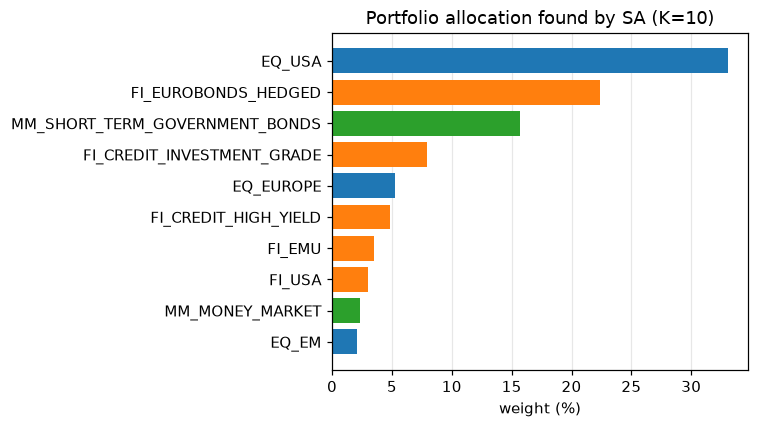

In [18]:
# Plot the SA portfolio as a horizontal bar chart, colored by asset class
print(f"Portfolio allocation found by SA (K={K})")
fig, ax = plt.subplots(figsize=(7, 4))
class_colors = {"EQ": "tab:blue", "FI": "tab:orange", "MM": "tab:green"}
bar_colors = [class_colors[c] for c in portfolio_df["class"]]
ax.barh(portfolio_df["label"], portfolio_df["weight(%)"], color=bar_colors)
ax.invert_yaxis()  # match portfolio_df's sort order: largest weight at the top
ax.set_xlabel("weight (%)")
ax.set_title(f"Portfolio allocation found by SA (K={K})")
ax.grid(axis="x", alpha=0.3)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

### Solving it on a real quantum annealer (QPU)

So far we've used a classical simulation (SA) from the D-Wave Ocean SDK. Let's now run the exact same round-based refinement procedure from Section 4 on an actual quantum annealing machine (QPU) instead — starting `k` from the same uniform value SA did, so the two are compared on equal footing — using your D-Wave Leap account and API token.

**Note**: this QUBO has M=140 binary variables, and the H2/H4 terms couple nearly all of them together (a dense graph). Because a QPU only has limited connectivity between physical qubits, each logical variable typically needs to be represented by a "chain" of several physical qubits (minor-embedding). For a problem this dense, finding an embedding can take a while, or may not succeed at all, depending on the chip's topology. If it doesn't work, try re-running (the embedding search is randomized) or ask the instructor.

**In the code**:

| | SA | QA |
|---|---|---|
| Class | `SimulatedAnnealingSampler()` | `EmbeddingComposite(DWaveSampler(...))` |
| Runs on | Software (CPU) | Real QPU |
| Embedding | Not needed | Required (handled automatically by `EmbeddingComposite`) |

The construction differs, but the call that actually solves the problem is identical either way:

```python
sampler = SimulatedAnnealingSampler()            # SA
sampler = EmbeddingComposite(DWaveSampler(...))  # QA

response = sampler.sample_qubo(Q)                # same call either way
```

**Providing your token in Google Colab**: click the key icon (🔑 Secrets) in the left sidebar, add a new secret named `DWAVE_API_TOKEN` with your token as the value, and enable "Notebook access" for it. The cell below will pick it up automatically. (Running locally instead of in Colab? Setting a `DWAVE_API_TOKEN` environment variable works the same way; otherwise you'll just be prompted to type it.)

In [ ]:
from dwave.system import DWaveSampler, EmbeddingComposite
import getpass
import os

token = None
try:
    from google.colab import userdata  # only available when running in Google Colab
    token = userdata.get("DWAVE_API_TOKEN")
except Exception:
    pass
if not token:
    token = os.environ.get("DWAVE_API_TOKEN") or getpass.getpass("D-Wave Leap API token: ")
# Unlike SA below (rebuilt fresh every round, since that's essentially free), connecting to the real QPU
# needs a network handshake and authentication, so we build it once here and reuse it across all 5 rounds.
# Note that the embedding itself is still recomputed on every sample_qubo() call below.
qpu_sampler = EmbeddingComposite(DWaveSampler(token=token, solver=dict(qpu=True)))

# Mirror the SA loop above, but starting k from the same uniform value and using the QPU as the sampler,
# so SA and QA are compared on equal footing
qpu_best = None
k_linear_qpu = np.full(n, 1.0 / n)
rate = 0.5
try:
    for round_ in range(5):
        # Only H4 depends on k, so rebuild Q4/off4 with this round's k and recombine with Q1-Q3
        kSigma = k_linear_qpu @ sigma
        c = np.zeros(M)
        const = 0.0
        for i in range(n):
            c += kSigma[i] * w_vecs[i]
            const += kSigma[i] * w_consts[i]
        for k in range(S_vol):
            c[index[f"s4_{k}"]] = target2 * p_Sv * (2**k)
        const -= target2
        Q4_qpu = np.outer(c, c) + 2.0 * const * np.diag(c)
        off4_qpu = const ** 2

        Q_qpu = (lambdas["return"] * Q1 + lambdas["budget"] * Q2
                 + lambdas["class"] * Q3 + lambdas["vol"] * Q4_qpu)
        offset_qpu = (lambdas["return"] * off1 + lambdas["budget"] * off2
                      + lambdas["class"] * off3 + lambdas["vol"] * off4_qpu)

        # Solve with the QPU (1000 reads), matching the number of reads SA uses above
        qpu_response = qpu_sampler.sample_qubo(Q_qpu, num_reads=1000)
        qpu_response = qpu_response.relabel_variables(dict(enumerate(var_names)), inplace=False)

        # Decode each read into a portfolio and check feasibility, same as in the SA loop above
        qpu_round_results = []
        for sample, energy, num_occ in qpu_response.record[["sample", "energy", "num_occurrences"]]:
            sample_dict = dict(zip(qpu_response.variables, sample))

            w = np.zeros(n)
            for i in range(n):
                frac = sum(p_K * (2**k) * sample_dict[f"w_{i}_{k}"] for k in range(K))
                w[i] = w_min[i] + (w_max[i] - w_min[i]) * frac

            norm_ok = abs(np.sum(w) - 1.0) <= p_K
            class_ok = True
            for cls, op, bound in class_constraints:
                total = sum(wi for wi, asset_cls in zip(w, classes) if asset_cls == cls)
                class_ok = class_ok and (total <= bound + 1e-9 if op == "<=" else total >= bound - 1e-9)
            volatility = float(np.sqrt(max(w @ sigma @ w, 0.0)))
            vol_ok = volatility <= SIGMA_TARGET + 1e-9
            feasible = norm_ok and class_ok and vol_ok

            qpu_round_results.append({"weights": w, "return": float(r @ w), "volatility": volatility, "feasible": feasible})

        qpu_feas_rate = sum(res["feasible"] for res in qpu_round_results) / len(qpu_round_results)
        qpu_feasible_results = [res for res in qpu_round_results if res["feasible"]]
        qpu_round_best = max(qpu_feasible_results, key=lambda res: res["return"]) if qpu_feasible_results else None

        msg = f"round {round_}: feasible_rate={qpu_feas_rate:.1%}"
        if qpu_round_best:
            msg += f"  best_return={qpu_round_best['return']:.4%}"
            if qpu_best is None or qpu_round_best["return"] > qpu_best["return"]:
                qpu_best = qpu_round_best
            k_linear_qpu = rate * k_linear_qpu + (1 - rate) * qpu_round_best["weights"]
        else:
            msg += "  no feasible solution"
        print(msg)

    print()
    if qpu_best:
        print(f"Final best solution: return={qpu_best['return']:.4%}, volatility={qpu_best['volatility']:.4%}  "
              f"(target={SIGMA_TARGET:.4%})")
    else:
        print("No feasible solution was found.")
except Exception as e:
    print(f"Something went wrong running on the QPU: {e}")
    print("If no embedding could be found, try re-running, or ask the instructor.")

In [20]:
# Same as above, but for QA's allocation (only runs if the QPU found a feasible solution)
if "qpu_best" in globals() and qpu_best:
    from IPython.display import display
    qpu_portfolio_df = pd.DataFrame({"label": labels, "class": classes, "weight(%)": qpu_best["weights"] * 100})
    qpu_portfolio_df = qpu_portfolio_df[qpu_portfolio_df["weight(%)"] > 0.1].sort_values("weight(%)", ascending=False)
    display(qpu_portfolio_df.round(1))

,label,class,weight(%)
9,MM_SHORT_TERM_GOVERNMENT_BONDS,MM,22.6
0,EQ_USA,EQ,20.4
3,FI_USA,FI,16.7
7,FI_EUROBONDS_HEDGED,FI,9.2
8,MM_MONEY_MARKET,MM,8.6
5,FI_CREDIT_HIGH_YIELD,FI,7.9
1,EQ_EUROPE,EQ,7.8
4,FI_CREDIT_INVESTMENT_GRADE,FI,6.4
6,FI_EMU,FI,0.4


Portfolio allocation found by QA (real QPU)


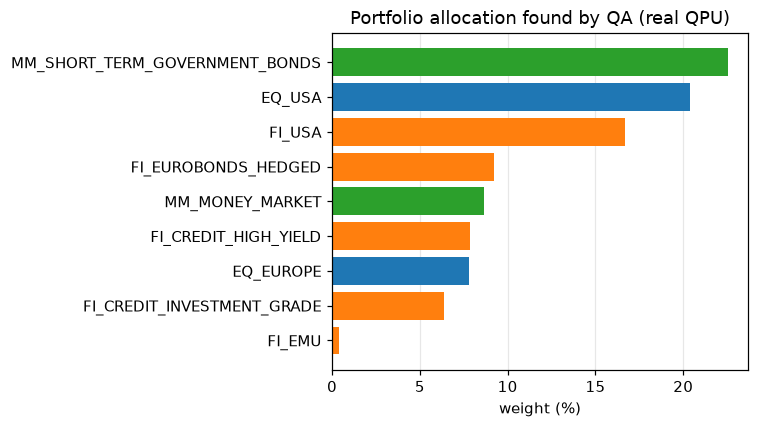

In [21]:
# Plot QA's portfolio the same way as SA's, for a like-for-like comparison
if "qpu_best" in globals() and qpu_best:
    print("Portfolio allocation found by QA (real QPU)")
    fig, ax = plt.subplots(figsize=(7, 4))
    bar_colors = [class_colors[c] for c in qpu_portfolio_df["class"]]
    ax.barh(qpu_portfolio_df["label"], qpu_portfolio_df["weight(%)"], color=bar_colors)
    ax.invert_yaxis()  # match qpu_portfolio_df's sort order: largest weight at the top
    ax.set_xlabel("weight (%)")
    ax.set_title("Portfolio allocation found by QA (real QPU)")
    ax.grid(axis="x", alpha=0.3)
    ax.set_axisbelow(True)
    fig.tight_layout()
    plt.show()

## 5. Backtesting: What Was the Actual Asset Allocation?

The asset allocation identified in Section 4 was determined using data from 4 June 2013 to 31 December 2024. Here, we will simulate how the portfolio’s value would have fluctuated if this allocation had been applied directly to the **actual price movements** from 1 January 2025 onwards—data that was not used at all in the optimisation process.

For the purposes of this analysis, we assume that we bought assets using this allocation on the first day of the backtesting period and held them continuously thereafter (**no rebalancing** = even if the proportion of assets that have risen in value increases automatically, we do not buy or sell during the period to restore the original proportions). For comparison, we also calculate the results for the QA (real QPU) allocation from the previous section, if one was found, and for a scenario where ‘all assets were invested in equally’.

How to interpret the output below:

| Metric | Meaning |
|---|---|
| Cumulative Return | The percentage change in value over the entire backtesting period |
| Annualised Rate | The rate of that change converted to an annualised figure (to facilitate comparison between experiments with different backtesting periods) |
| Annualised Volatility | The volatility of price movements during that period, annualised |

In [22]:
# Fetch price data for the validation period (read from cache if available)
end_test = dt.date.today().isoformat()
cache_file = CACHE_DIR / f"prices_{TEST_START}_{end_test}.csv"
if cache_file.exists():
    test_prices = pd.read_csv(cache_file, index_col=0, parse_dates=True)[tickers]
else:
    raw = yf.download(tickers, start=TEST_START, end=end_test, progress=False, auto_adjust=True)["Close"]
    test_prices = raw[tickers].dropna()
    test_prices.to_csv(cache_file)

test_log_returns = np.log(test_prices / test_prices.shift(1)).dropna()

# Compare SA's allocation against a naive equal-weight baseline; add QA's if it found a feasible solution
portfolios = {"SA": best["weights"], "Equal-weight": np.full(n, 1.0 / n)}
if "qpu_best" in globals() and qpu_best:
    portfolios["QA"] = qpu_best["weights"]

print(f"Validation period: {test_log_returns.index.min().date()} to {test_log_returns.index.max().date()}"
      f" ({len(test_log_returns)} trading days, future data never used for optimization)\n")

equity_curves = {}
for name, w in portfolios.items():
    daily_port_log_return = test_log_returns.to_numpy() @ w
    equity = np.exp(np.cumsum(daily_port_log_return))
    equity_curves[name] = equity
    total_return = equity[-1] - 1.0
    ann_return = daily_port_log_return.mean() * TRADING_DAYS_PER_YEAR
    ann_vol = daily_port_log_return.std() * np.sqrt(TRADING_DAYS_PER_YEAR)
    print(f"{name:14s}: cumulative return={total_return:+.2%}  annualized={ann_return:+.2%}  annualized volatility={ann_vol:.2%}")

Validation period: 2025-01-03 to 2026-08-21 (409 trading days, future data never used for optimization)

SA            : cumulative return=+17.01%  annualized=+9.68%  annualized volatility=7.61%
Equal-weight  : cumulative return=+16.72%  annualized=+9.52%  annualized volatility=6.41%
QA            : cumulative return=+14.69%  annualized=+8.44%  annualized volatility=5.69%


Backtest: simulated using actual prices from 2025-01-01 onward


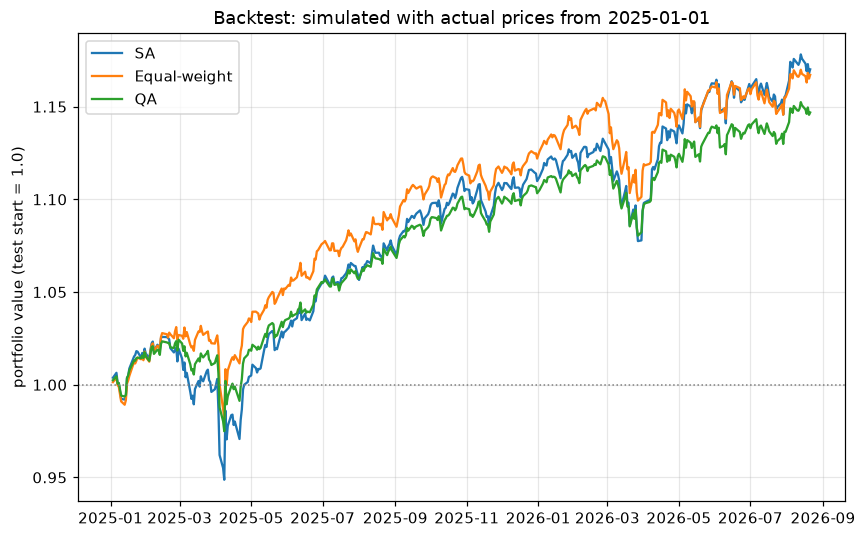

In [23]:
# Plot each portfolio's cumulative value over the validation period
print(f"Backtest: simulated using actual prices from {TEST_START} onward")
fig, ax = plt.subplots(figsize=(8, 5))
for name, equity in equity_curves.items():
    ax.plot(test_log_returns.index, equity, label=name)
ax.axhline(1.0, color="gray", linestyle=":", linewidth=1)
ax.set_ylabel("portfolio value (test start = 1.0)")
ax.set_title(f"Backtest: simulated with actual prices from {TEST_START}")
ax.legend()
ax.grid(alpha=0.3)
ax.set_axisbelow(True)
fig.tight_layout()
plt.show()

## 6. Summary

In this notebook,

we have walked through a series of steps in which we formulated a portfolio optimisation problem as a QUBO, determined the optimal investment allocation using both simulated annealing (SA) and a real quantum annealer (QA), and evaluated the results through backtesting.

Specifically, we carried out the following four steps:

1. We converted the portfolio optimisation problem into a QUBO and formulated the objective of ‘maximising returns whilst minimising risk’ in a form that could be solved using quantum annealing. (Section 3)
2. We optimised the QUBO using simulated annealing (SA), then ran the same procedure on an actual quantum annealer (QA) using a real D-Wave QPU, implementing an algorithm to actually search for the optimal solution. (Section 4)
3. Using ETF price data from 4 June 2013 to 31 December 2024, we calculated the optimal investment allocation for each asset and constructed the portfolio. (Section 4)
4. We conducted a backtest using data from 1 January 2025 onwards to verify how the portfolio obtained through optimisation would perform over an unknown period, comparing SA, QA, and an equal-weight baseline. (Section 5)

Through this series of steps, we were able to gain practical experience in constructing a QUBO from real-world data, optimising it using both classical simulation and real quantum hardware, and evaluating its performance.

### References and videos

1.   Sakuler, W., Oberreuter, J. M., Aiolfi, R., Asproni, L., Roman, B., & Schiefer, J. (2025). A real-world test of portfolio optimization with quantum annealing. Quantum Machine Intelligence, 7(1), 43.
2.   Portfolio qubo long full, https://www.youtube.com/watch?v=z91eoCY_Nuw